### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P307 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

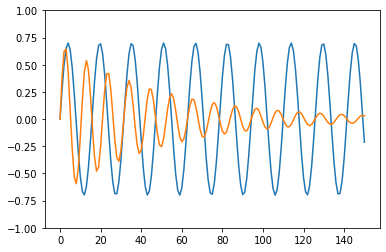

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 9

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

307

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0005008317274151233   1.5679571628570557 sec      
199: 0.0002949557064785227   2.2229104042053223 sec       
299: 0.0002043169578787355   2.842233657836914 sec        
399: 0.0001533554922938868   3.4676904678344727 sec       
499: 0.00012538955761934474   4.077397108078003 sec       
599: 0.0001087537197685808   4.690697908401489 sec        
699: 0.00010698269641766778   5.297289848327637 sec       
799: 9.194759828701107e-05   5.890666246414185 sec        
899: 8.569178083914469e-05   6.548135042190552 sec       
999: 0.00012522938013462224   7.198353052139282 sec      
1099: 7.639556445377768e-05   7.898038387298584 sec       
1199: 7.16073773351439e-05   8.590167045593262 sec        
1299: 0.000157575423028369   9.207432270050049 sec        
1399: 6.251333576442786e-05   9.863749742507935 sec       
1499: 5.8001810238395016e-05   10.599758863449097 sec      
1599: 5.419177890320709e-05   11.349430322647095 sec       
1699: 5.1550180286895506e-05   12.05990

26499: 4.7175734562150115e-05   175.67062902450562 sec      
26599: 4.302563123928943e-05   176.34389972686768 sec       
26699: 0.0010999281859964912   176.99653029441833 sec       
26799: 5.035249270538387e-05   177.6498463153839 sec        
26899: 4.5223657872793545e-05   178.29550909996033 sec      
learning rate: 0.1
26999: 0.00016253633859012576   178.96541285514832 sec      
27099: 0.00012609586373811405   179.6120569705963 sec       
27199: 0.00010932971344058479   180.32518315315247 sec      
learning rate: 0.05
27299: 6.427478313351702e-05   180.98305320739746 sec       
27399: 5.1307773876631954e-05   181.6381859779358 sec       
27499: 4.775722256712353e-05   182.28864288330078 sec       
27599: 4.540320909493197e-05   182.93998289108276 sec       
27699: 4.3399131439028975e-05   183.60319781303406 sec      
27799: 4.344166092488899e-05   184.25643134117126 sec       
27899: 4.046000176899291e-05   184.93370294570923 sec       
27999: 3.8744046879297435e-05   185.5820500850

52399: 0.0004193073202751149   348.05726289749146 sec       
52499: 0.00017520644576333633   348.74392652511597 sec      
52599: 0.00012698138466539033   349.3947205543518 sec       
52699: 0.00010341962022248837   350.0567169189453 sec       
52799: 8.617167753572028e-05   350.7127501964569 sec        
52899: 0.0002262679738964882   351.3872654438019 sec        
52999: 0.0001102447293046184   352.060054063797 sec         
53099: 9.140610725743752e-05   352.7141180038452 sec        
learning rate: 0.1
53199: 0.0005027092019399802   353.3748993873596 sec       
53299: 0.0002175989679548066   354.04993510246277 sec       
53399: 0.0001534764195360756   354.6874260902405 sec        
learning rate: 0.05
53499: 0.00018236065541210058   355.3767657279968 sec       
53599: 0.00012185450261333028   356.04917073249817 sec      
53699: 0.00010143890545394961   356.7237432003021 sec       
53799: 8.967271524203425e-05   357.3923604488373 sec        
53899: 8.115075037566402e-05   358.075537919998

78299: 0.00010216386632076468   519.1886303424835 sec      
78399: 9.124937338943379e-05   519.8808541297913 sec       
78499: 0.010790345597377664   520.5327613353729 sec        
78599: 0.001012301837329655   521.1790542602539 sec       
78699: 0.0006072013634324558   521.8230545520782 sec      
learning rate: 0.05
78799: 0.017513493564476342   522.4726543426514 sec       
78899: 0.0077558611374076184   523.116548538208 sec       
78999: 0.004935187615249336   523.8234627246857 sec       
learning rate: 0.025
79099: 0.00015982250949329602   524.487714767456 sec       
79199: 0.00013359702642614385   525.129723072052 sec       
79299: 0.00011852990340204584   525.7744770050049 sec      
79399: 0.00010766908691640009   526.4334423542023 sec      
79499: 9.898839689246266e-05   527.0732927322388 sec       
79599: 9.211800396809255e-05   527.7217981815338 sec      
79699: 8.675670613596534e-05   528.4503877162933 sec      
79799: 8.052772951875995e-05   529.1181254386902 sec      
79899: 

104599: 3.541240542115262e-05   693.9102954864502 sec       
104699: 3.4444883253856926e-05   694.5700881481171 sec      
104799: 3.395187791998683e-05   695.2453398704529 sec       
104899: 4.638852955109005e-05   695.9011189937592 sec       
104999: 3.6604984797000665e-05   696.5745894908905 sec      
105099: 3.434657480244735e-05   697.2306287288666 sec       
learning rate: 0.1
105199: 0.0003510334626318941   697.9077990055084 sec       
105299: 0.00011777651085035237   698.5549058914185 sec      
105399: 8.110659252095943e-05   699.2113356590271 sec       
learning rate: 0.05
105499: 0.00021079682597581562   699.9219148159027 sec      
105599: 6.350414350430986e-05   700.6257638931274 sec       
105699: 4.276417105320166e-05   701.3020403385162 sec       
105799: 3.7158197220189784e-05   702.0650918483734 sec      
105899: 3.5286855856394965e-05   702.8107006549835 sec      
105999: 3.445722338771302e-05   703.5169005393982 sec       
106099: 3.401975072615623e-05   704.1883234977

130899: 8.161265930796933e-05   867.6462550163269 sec       
130999: 6.085354195410866e-05   868.294239282608 sec       
learning rate: 0.025
131099: 3.9639397201872655e-05   868.9279518127441 sec      
131199: 3.538939118535905e-05   869.5671861171722 sec       
131299: 3.438281512351612e-05   870.2039933204651 sec       
131399: 3.3955729052059875e-05   870.849903345108 sec       
131499: 3.3720371310513826e-05   871.4804611206055 sec      
131599: 3.356714509797579e-05   872.1440591812134 sec       
131699: 3.3455083836236954e-05   872.7922930717468 sec      
learning rate: 0.2
131799: 0.007118464575828838   873.449355840683 sec        
131899: 0.002189609153419552   874.0961077213287 sec       
131999: 0.0009341240103873519   874.7400562763214 sec      
132099: 0.0007350230492810186   875.3762731552124 sec      
132199: 0.00047346498448773536   876.039350271225 sec       
132299: 0.01023274098712965   876.6859095096588 sec         
132399: 0.00040565254631776696   877.3155980110168

156999: 4.742014516965327e-05   1044.882238149643 sec        
157099: 6.601787754152808e-05   1045.7258484363556 sec       
157199: 5.35843841196333e-05   1046.4873216152191 sec        
157299: 4.771063340720591e-05   1047.2272346019745 sec       
learning rate: 0.1
157399: 0.0005260021115469923   1047.9235980510712 sec      
157499: 0.00021867883948189514   1048.6588554382324 sec      
157599: 0.0010844128912083394   1049.3718829154968 sec       
learning rate: 0.05
157699: 0.00013696699217544941   1050.0896925926208 sec      
157799: 8.289587205587545e-05   1050.8186509609222 sec       
157899: 6.384187677521524e-05   1051.5354025363922 sec      
157999: 5.4840727926853916e-05   1052.3497805595398 sec      
158099: 4.8429151978608904e-05   1053.0717175006866 sec      
158199: 4.3557905040611176e-05   1053.8276648521423 sec      
158299: 3.982280749000597e-05   1054.5332231521606 sec       
158399: 3.711402536215519e-05   1055.2428705692291 sec       
158499: 3.538514092862064e-05   1

182699: 5.599217779778762e-05   1234.5721006393433 sec       
182799: 4.1917623761185036e-05   1235.2392137050629 sec      
182899: 3.84456980289211e-05   1235.9168047904968 sec        
182999: 3.65322184073869e-05   1236.63010430336 sec          
183099: 3.532928828109764e-05   1237.312487602234 sec        
183199: 3.464126917766576e-05   1238.0074632167816 sec       
183299: 3.423243401879988e-05   1238.6941883563995 sec       
183399: 3.396223397555364e-05   1239.3845314979553 sec       
183499: 7.870250712250642e-05   1240.0913569927216 sec       
183599: 3.383393163868594e-05   1240.7822082042694 sec       
183699: 3.358196696365637e-05   1241.4670011997223 sec       
183799: 3.3464503793678396e-05   1242.167088508606 sec       
183899: 3.338481621921648e-05   1242.8970611095428 sec       
learning rate: 0.2
183999: 0.00046416500424809325   1243.5665774345398 sec      
184099: 0.00016742238378555593   1244.248966217041 sec       
184199: 8.358120988682261e-05   1244.905990600586 s

In [23]:
minLoss

Array(3.30758195e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

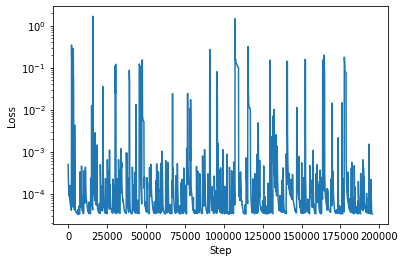

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

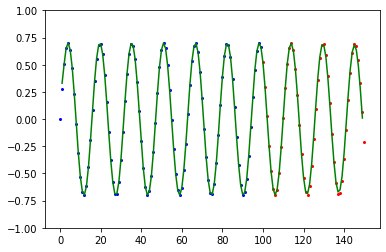

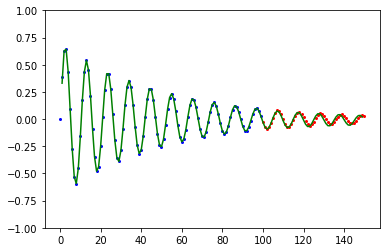

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

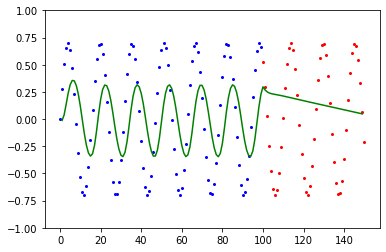

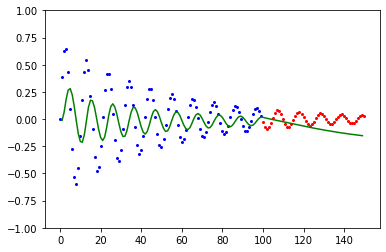

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[163000,
 Array(3.33166352e-05, dtype=float64),
 Array(2.70702763e-05, dtype=float64),
 [((Array([[ 1.09025659, -0.73614053,  2.87851278,  0.64468777,  0.21440699,
             0.17427503, -0.29168052, -0.48570394, -1.64500738]],      dtype=float64),
    Array([[ 1.7186152 , -0.96070508,  1.71531398, -0.90581139,  0.34533803,
             0.89291905,  0.50805066,  1.35707392, -2.95794556],
           [ 0.19473464, -0.32520342,  2.02771119,  0.48968374,  0.95161511,
            -0.89761047,  0.7406153 ,  1.6185873 ,  1.11966878],
           [ 0.22040874, -1.26596011, -0.71197711,  0.55918869,  1.08413405,
             1.72154598, -0.01612118, -0.85684089,  0.41821348],
           [-1.56718879,  1.09772275, -1.68453461,  1.23245358, -0.98945986,
            -0.17466281, -0.05873967, -2.1408122 , -2.0798658 ],
           [-0.70591512, -0.40219113, -1.08354128, -1.21616338,  0.21351449,
             1.77819009, -0.37752135, -0.55791957, -0.68735461],
           [-0.52720294,  1.84140166, -

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

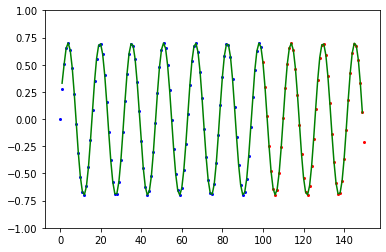

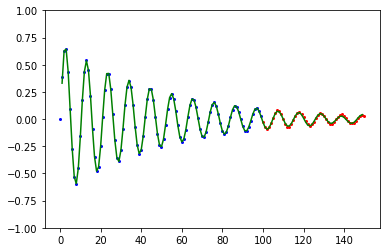

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [163000, Array(3.33166352e-05, dtype=float64), Array(2.70702763e-05, dtype=float64)]
7600 3.3140321591967125e-05 6.527135856669995e-05


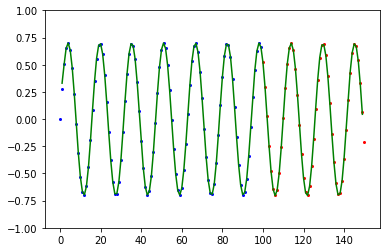

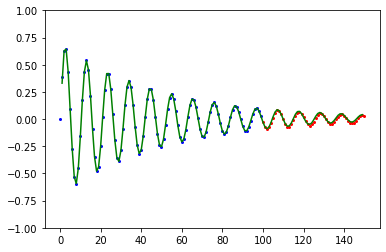

10100 3.3562129290936343e-05 0.00288693956278914


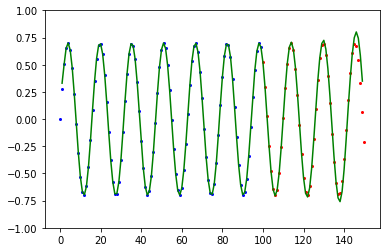

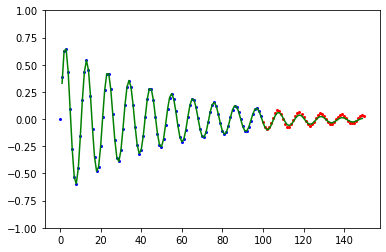

14500 3.344582041026137e-05 0.0006879533830736124


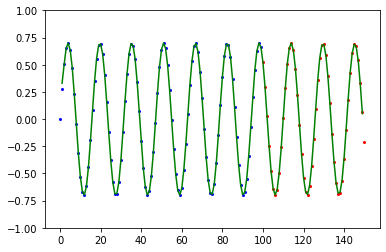

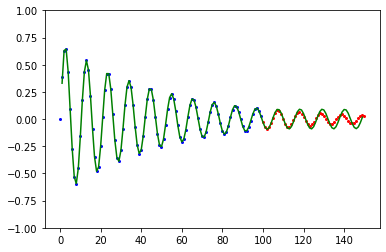

20700 3.377108855553431e-05 0.0002584190162342447


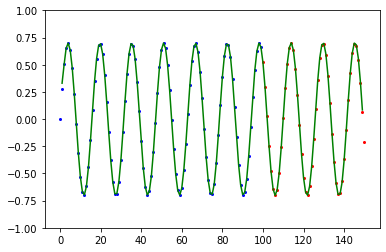

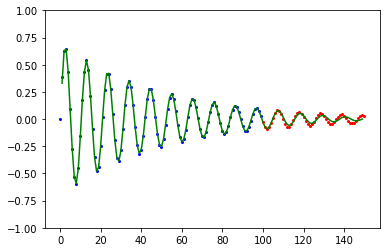

25200 3.3393409631921696e-05 0.0003362466646186992


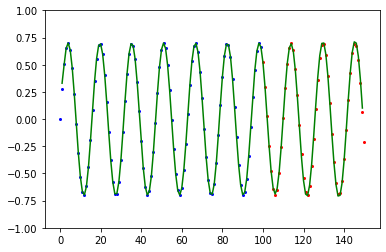

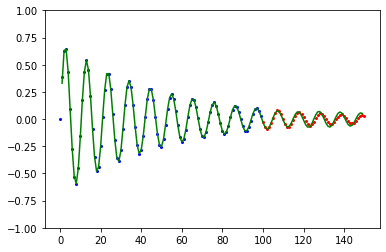

28700 3.449249038527742e-05 0.006549122674182542


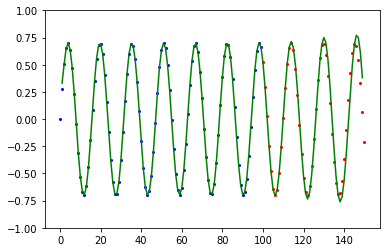

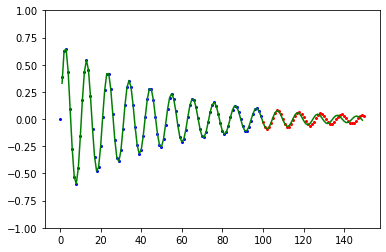

31300 3.3406207692164626e-05 0.0004101423560398011


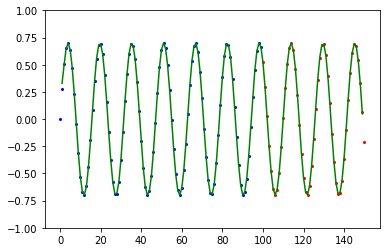

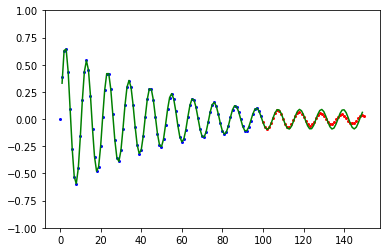

33500 3.4040534453024825e-05 0.00013785411139593542


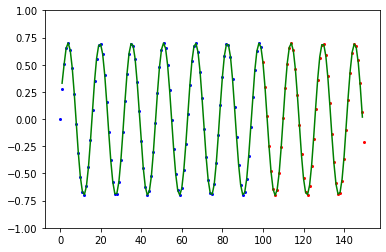

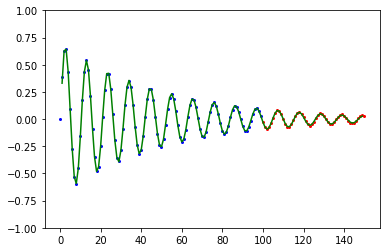

37400 3.4015696944202435e-05 0.0011249349494733565


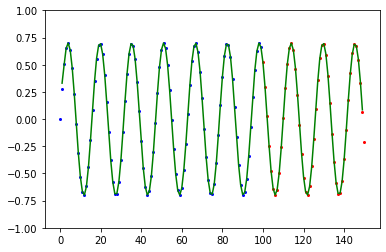

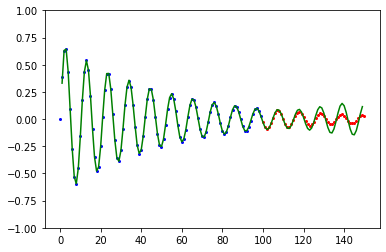

41300 3.3401074480699725e-05 0.0002244704953243607


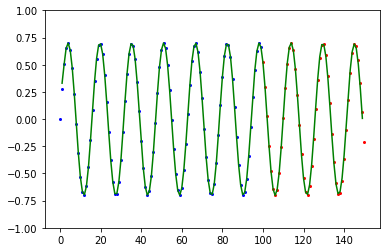

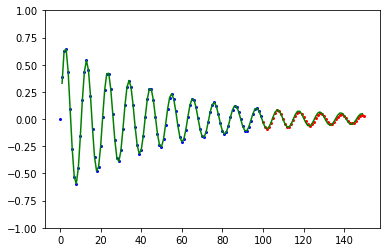

45700 3.367810790979934e-05 0.0022486046783449895


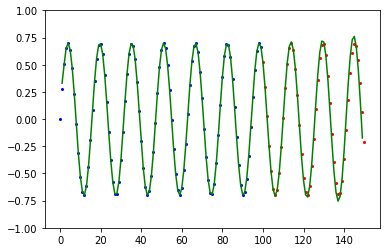

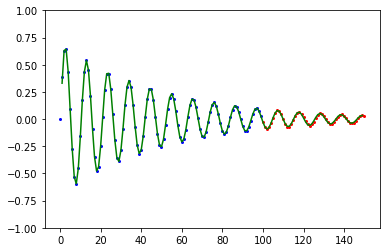

46600 0.10790602481681207 0.2420452803273455


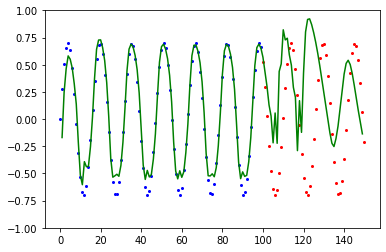

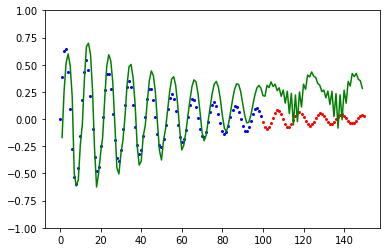

48800 0.005246714424420294 0.01013255046561791


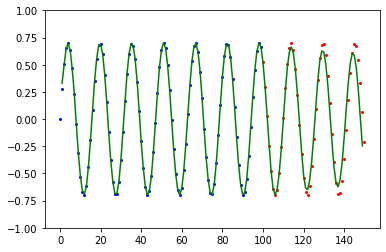

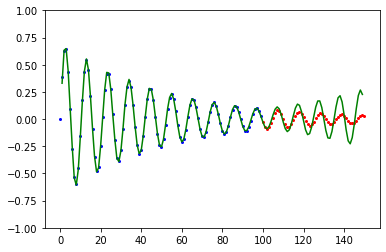

52300 3.349193340406619e-05 0.002259257261828915


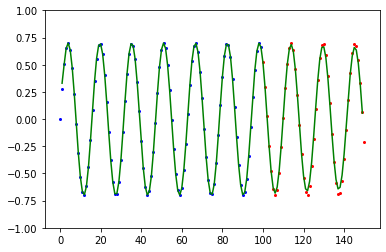

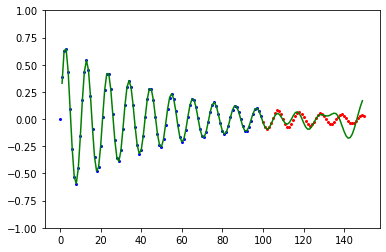

56600 3.387893507607547e-05 0.0019155780022886149


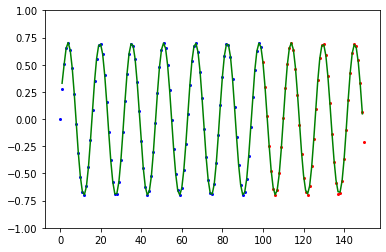

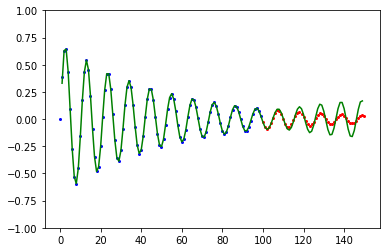

59500 3.421490918257057e-05 0.0008937134200770171


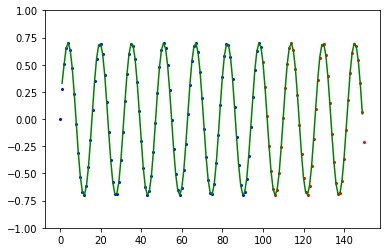

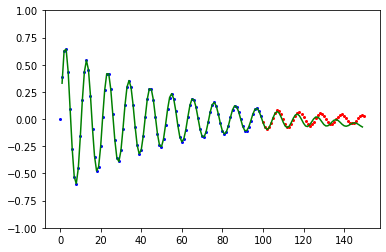

62700 3.326386445565782e-05 0.00039210305209124124


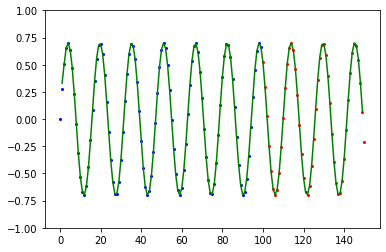

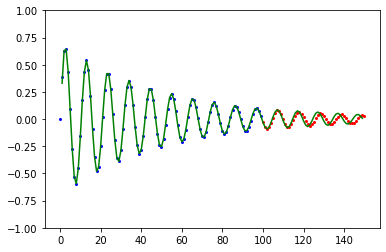

66800 3.351615518172628e-05 0.00026419902250201177


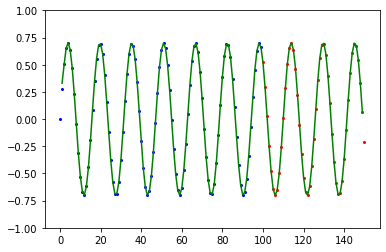

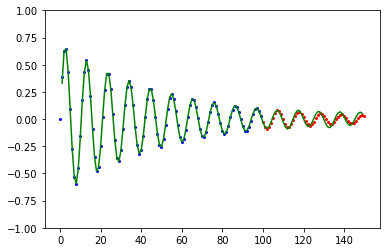

69300 3.4151748152167854e-05 0.000866382962943275


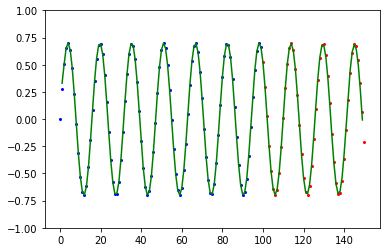

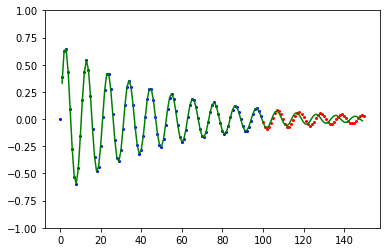

72600 3.33858757043172e-05 0.000363868816660202


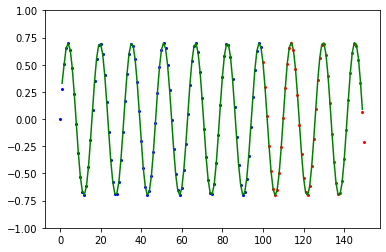

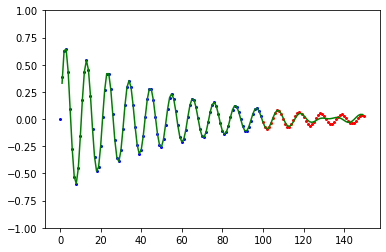

76200 3.334808786952824e-05 0.00021926332244737168


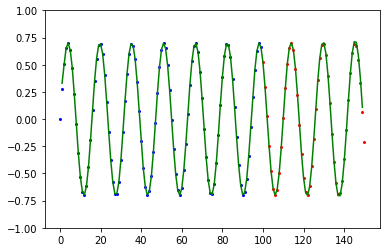

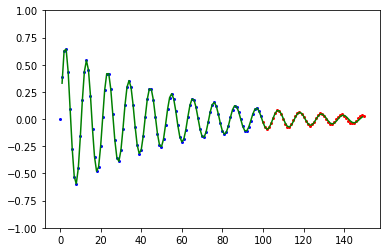

83200 3.4065983254660126e-05 0.1712338505517099


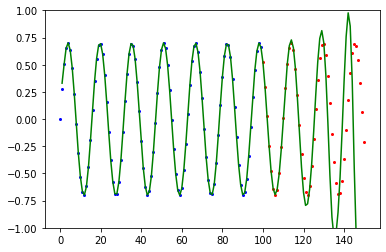

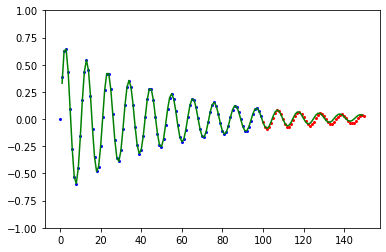

86400 3.377391750715877e-05 0.0016711251224174255


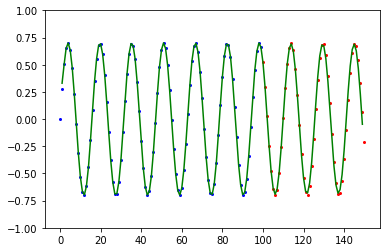

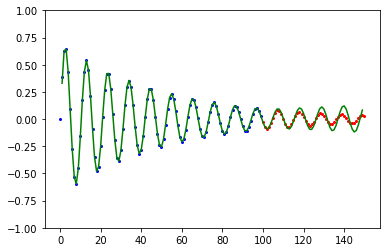

89800 3.3675631112990554e-05 0.0029346947384498753


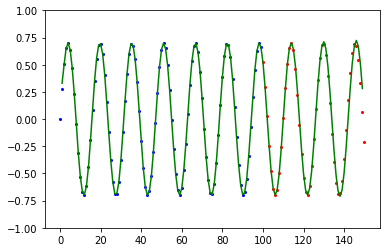

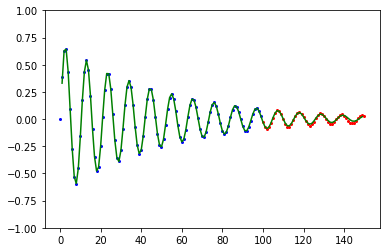

93900 3.370145815023849e-05 0.0008792035901998923


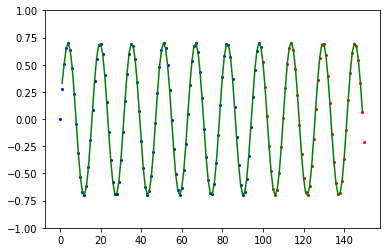

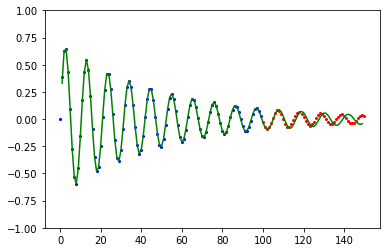

99300 3.3634726713831015e-05 0.0007592072479802864


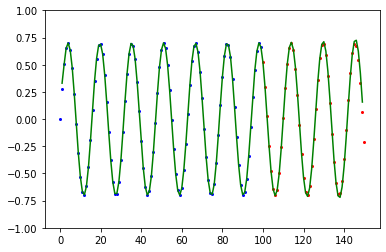

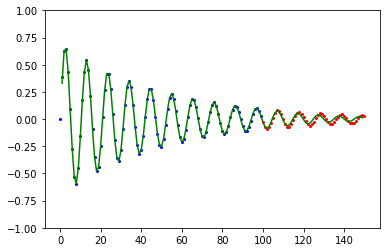

100800 3.324769522030053e-05 0.0003105933426706469


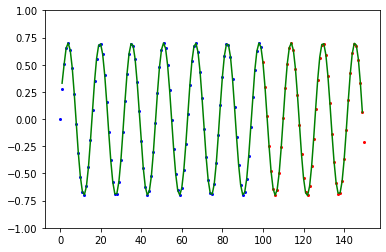

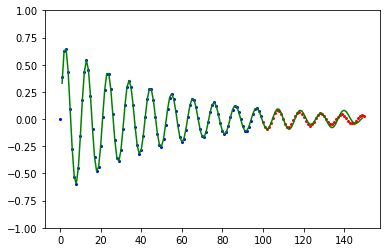

103700 3.3082331134673236e-05 0.00042191900101741546


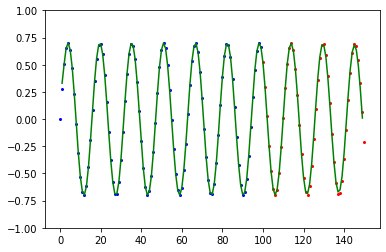

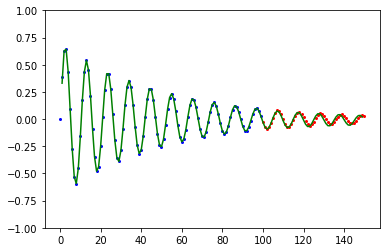

106400 3.3450317627570004e-05 0.00782640088338354


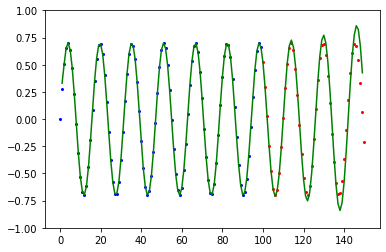

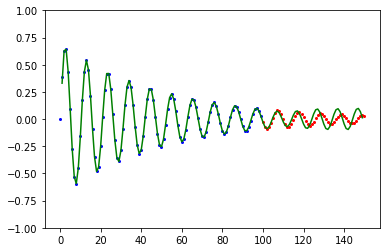

109600 0.10131854266500419 0.008157003334136288


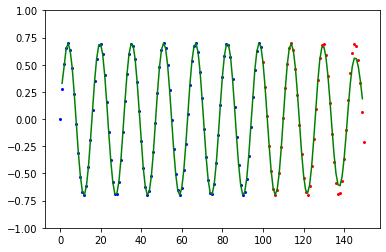

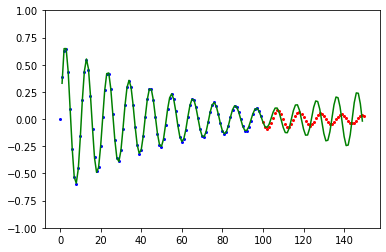

114400 3.319339852589863e-05 0.00016331107367821522


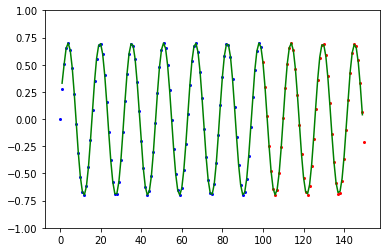

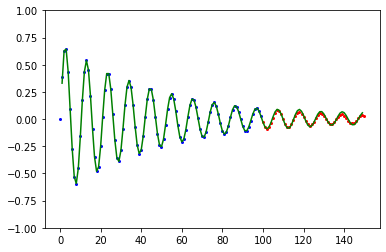

117200 0.010483778977856968 0.10784705402111511


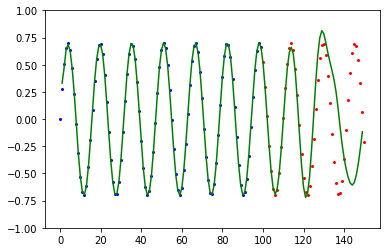

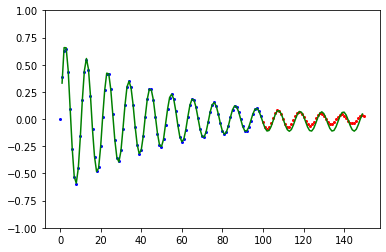

120000 3.337154578747003e-05 0.0004575722093996829


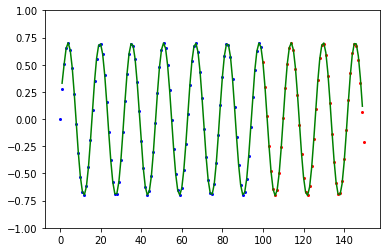

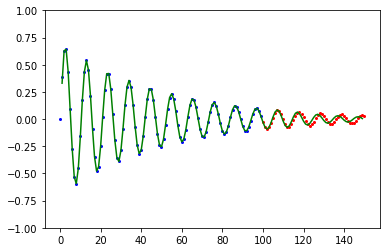

128500 3.329422050777849e-05 0.00047345655915228684


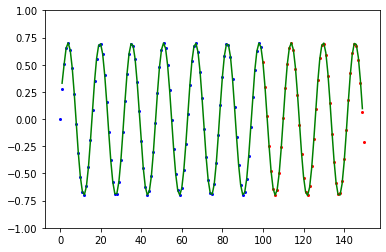

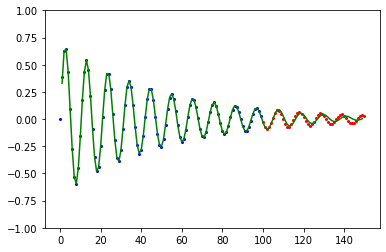

131700 3.3455083836236954e-05 0.0009292239883861092


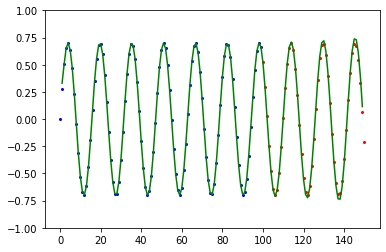

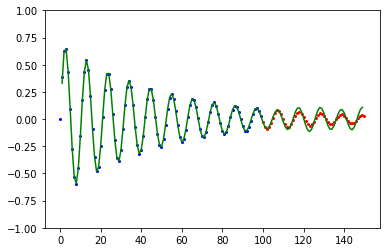

137300 3.640063779231501e-05 0.007130894957356774


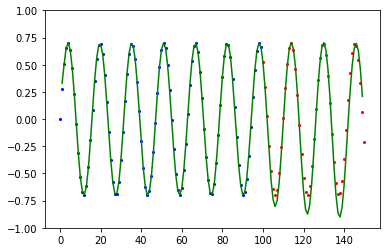

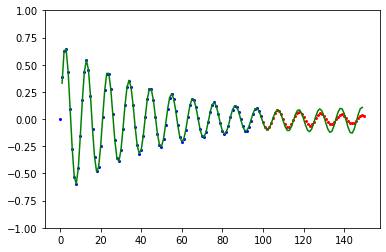

140200 3.346759933309566e-05 6.165954029837796e-05


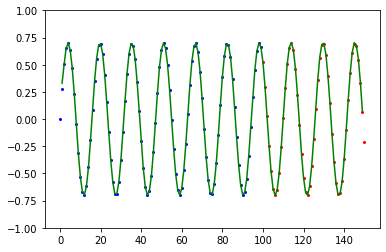

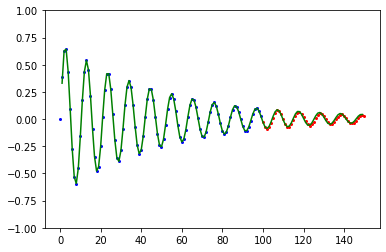

146900 3.5022980875589374e-05 0.02836774400465959


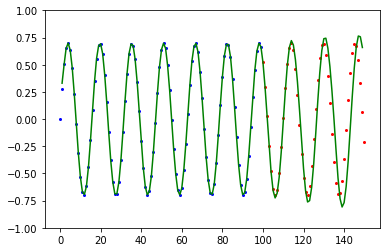

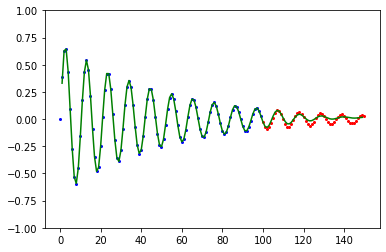

151400 3.405692590785033e-05 0.09970011073729036


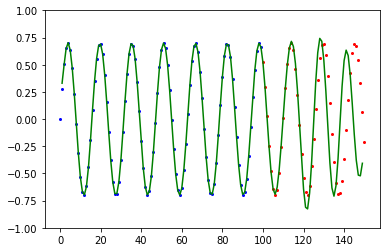

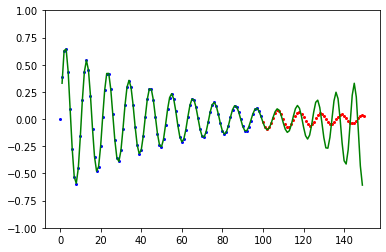

155300 3.334377803936799e-05 0.0001488792418996487


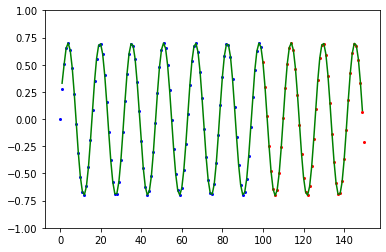

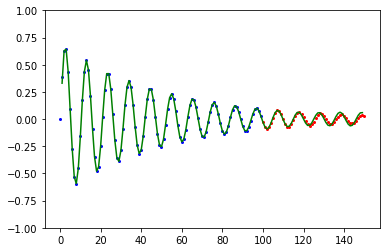

159300 3.3352648550197625e-05 0.000594400949219709


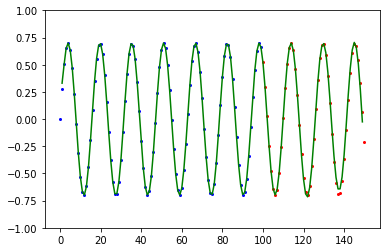

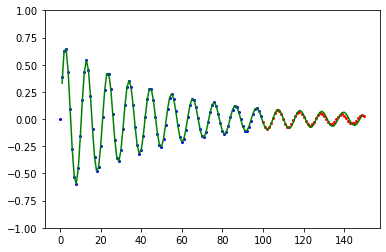

163000 3.331663516279895e-05 2.7070276267449506e-05


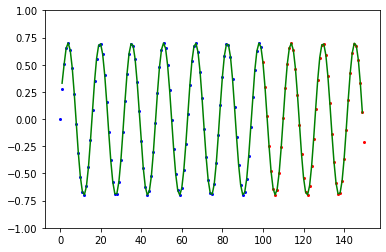

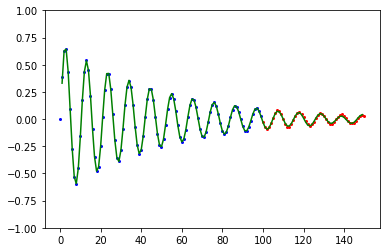

168800 3.60167452197707e-05 0.03503408074813653


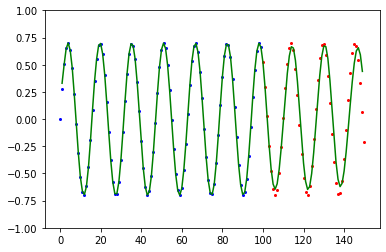

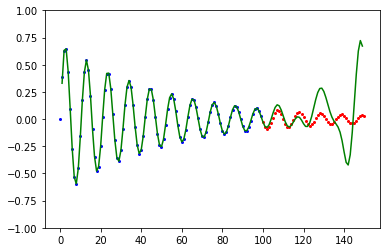

173400 3.3845260512488215e-05 0.04540298603649503


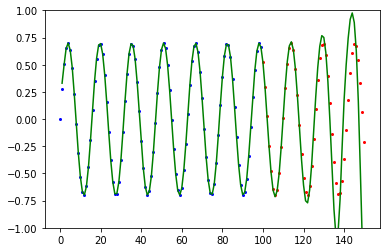

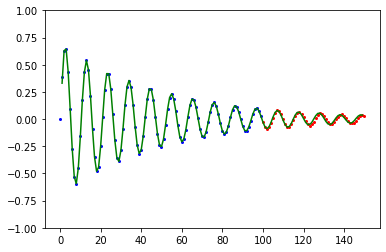

176600 3.3123207913889814e-05 0.0003210911127785737


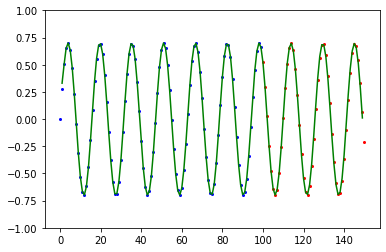

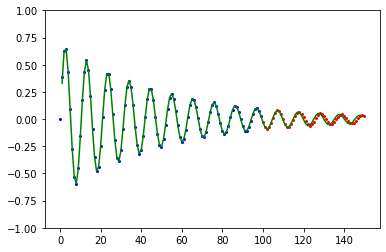

178700 0.07697560328012658 0.0893815710390418


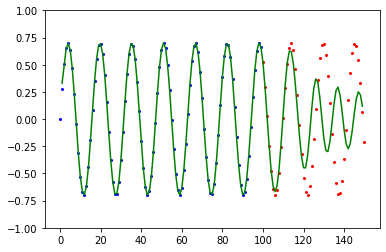

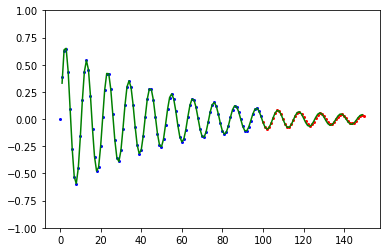

183900 3.338481621921648e-05 0.0003742669760206873


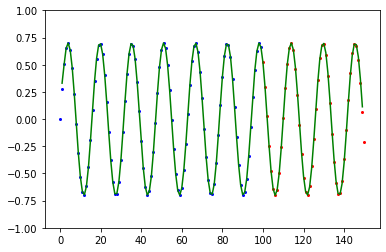

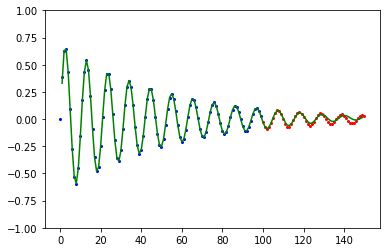

188000 3.331794679870707e-05 0.00015718656250776294


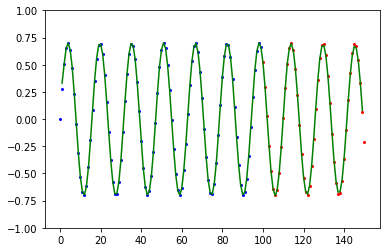

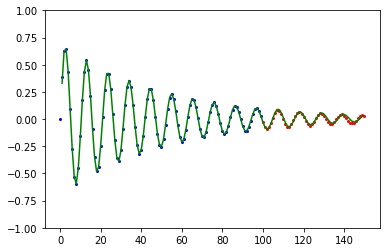

193100 3.405581780325407e-05 0.017009475918955762


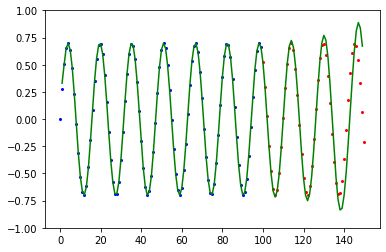

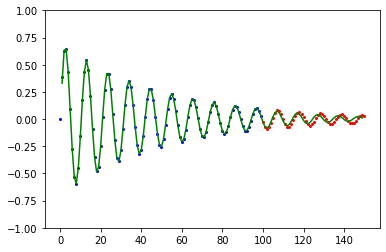

195700 3.3171917993059286e-05 0.0003369867741262868


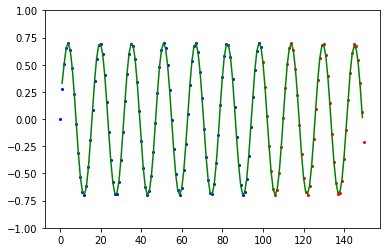

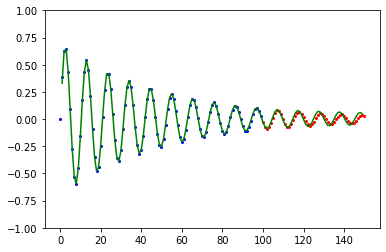

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.0180479, dtype=float64)

In [35]:
len(test_result)

50